In [ ]:
# Instalar la librería spaCy
!pip install spacy
# Descargar el modelo de spaCy para español
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 82.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#Importación de las librerías necesarias

import spacy # Librería para procesamiento de lenguaje natural
import matplotlib.pyplot as plt # Librería para la creación de gráficos
from collections import Counter # Utilidad para contar la frecuencia de elementos
from itertools import islice # Utilidad para trabajar con iteradores
import re # Módulo para expresiones regulares
import unicodedata # Módulo para normalización de texto Unicode
from nltk.stem import SnowballStemmer # Stemmer para el idioma español
from nltk.util import ngrams #Utilidad para generar n-gramas

In [ ]:
# Inicializar el stemmer para español
stemmer = SnowballStemmer("spanish")

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

In [ ]:
# Nombre del archivo cargado
nombre_archivo = "textos.txt"

# Leer el contenido del archivo y preprocesar el texto
with open(nombre_archivo, "r", encoding="utf-8") as f:
    texto = f.read()
    # Eliminar la secuencia "===" del texto, que el divisor propuesto para los textos
    texto = texto.replace("===", "")

In [ ]:
# Procesar el texto con spaCy para crear un objeto 'doc'
doc = nlp(texto)

# Extraer tokens del documento, excluyendo espacios
tokens = [
    token.text
    for token in doc
    if not token.is_space
]

In [ ]:
# Calcular el número total de tokens
total_tokens = len(tokens)
print("Total de tokens:", total_tokens)

Total de tokens: 10173


In [ ]:
# Calcular el número de tokens únicos (vocabulario)
tokens_unicos = len(set(tokens))
print("Número de tokens únicos:", tokens_unicos)

Número de tokens únicos: 2641


In [ ]:
# Calcular la frecuencia de cada token
frecuencias = Counter(tokens)

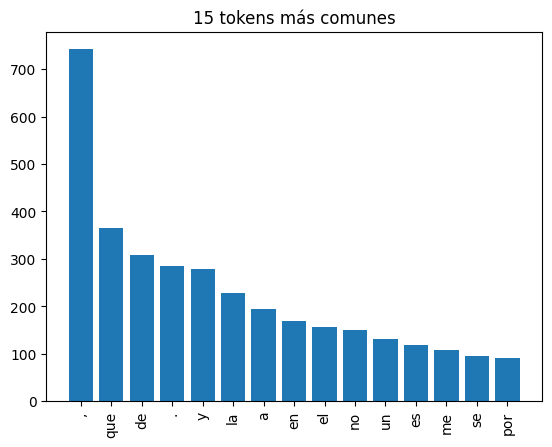

In [ ]:
# Obtener los 15 tokens más comunes
mas_comunes = frecuencias.most_common(15)

# Separar las palabras y sus valores para el gráfico
palabras = [x[0] for x in mas_comunes]
valores = [x[1] for x in mas_comunes]

# Crear y mostrar el gráfico de barras de los tokens más comunes
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens más comunes")
plt.show()

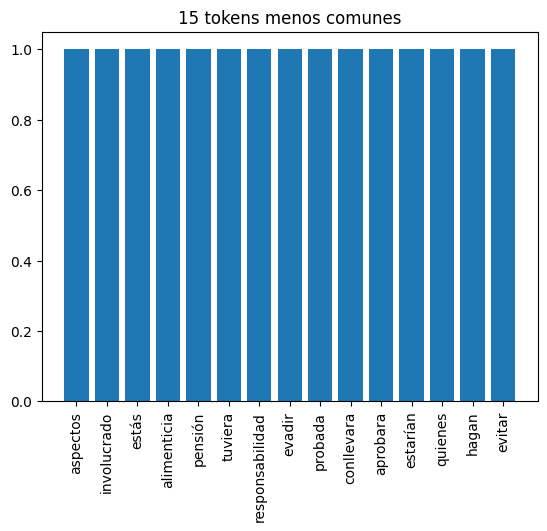

In [ ]:
# Obtener los 15 tokens menos comunes (invirtiendo la lista y tomando los primeros 15)
menos_comunes = list(reversed(frecuencias.most_common()))[:15]

# Separar las palabras y sus valores para el gráfico
palabras = [x[0] for x in menos_comunes]
valores = [x[1] for x in menos_comunes]

# Crear y mostrar el gráfico de barras de los tokens menos comunes
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens menos comunes")
plt.show()

In [ ]:
# Contar el número de tokens con una frecuencia de 1 (tokens raros)
tokens_raros = sum(1 for token, freq in frecuencias.items() if freq == 1)
print("Número de tokens raros (frecuencia = 1):", tokens_raros)

Número de tokens raros (frecuencia = 1): 1767


In [ ]:
# Crear bigramas
bigramas = zip(tokens, tokens[1:])
# Calcular la frecuencia de cada bigrama
frecuencia_bigramas = Counter(bigramas)

# Obtener los 15 bigramas más comunes
top_15_bigramas = frecuencia_bigramas.most_common(15)

# Imprimir los 15 bigramas más comunes
print("Top 15 Bigramas:")
for bg, freq in top_15_bigramas:
    print(bg, "->", freq)

Top 15 Bigramas:
(',', 'y') -> 33
('de', 'la') -> 32
(',', 'pero') -> 27
(',', 'no') -> 26
(',', 'la') -> 25
(',', 'el') -> 24
('que', 'me') -> 23
(',', 'en') -> 21
(',', 'que') -> 20
('que', 'no') -> 20
('en', 'la') -> 19
('a', 'la') -> 17
('lo', 'que') -> 17
(',', 'los') -> 17
('y', 'me') -> 15


In [ ]:
# Crear trigramas
trigramas = zip(tokens, tokens[1:], tokens[2:])
# Calcular la frecuencia de cada trigrama
frecuencia_trigramas = Counter(trigramas)

# Obtener los 15 trigramas más comunes
top_15_trigramas = frecuencia_trigramas.most_common(15)

# Imprimir los 15 trigramas más comunes
print("Top 15 Trigramas:")
for tg, freq in top_15_trigramas:
    print(tg, "->", freq)

Top 15 Trigramas:
('la', 'puerta', ',') -> 7
('la', 'casa', ',') -> 6
('de', 'la', 'cama') -> 4
('.', 'A', 'veces') -> 4
('la', 'noche', ',') -> 4
('a', 'todos', '.') -> 4
('por', 'lo', 'menos') -> 4
('me', 'di', 'cuenta') -> 3
('antes', 'de', 'dormir') -> 3
('de', 'dormir', ',') -> 3
(',', 'y', 'no') -> 3
(',', 'pero', 'no') -> 3
('a', 'decir', 'que') -> 3
('.', 'Eso', 'me') -> 3
('la', 'idea', 'de') -> 3


In [ ]:
# Convertir todo el texto a minúsculas
texto = texto.lower()

In [ ]:
# Eliminar caracteres que no sean letras del alfabeto español o espacios
texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

In [ ]:
# Normalizar el texto Unicode: descompone caracteres compuestos en su letra base y su marca diacrítica (acentos, diéresis, etc)
texto = unicodedata.normalize('NFD', texto)
# Codificar a ASCII y decodificar a UTF-8 para eliminar caracteres diacríticos
texto = texto.encode('ascii', 'ignore').decode('utf-8')

In [ ]:
# Eliminar caracteres repetidos mas de una vez seguida
texto = re.sub(r"(.)\1{2,}", r"\1", texto)

In [ ]:
# Procesar el texto normalizado con spaCy
doc = nlp(texto)

# Extraer tokens normalizados:
# - Lematizar el token (forma base de la palabra)
# - Aplicar stemming al lema
# - Excluir signos de puntuación, espacios, stop words
# - Excluir tokens con menos de 3 caracteres de longitud
tokens_norm = [
    stemmer.stem(token.lemma_)
    for token in doc
    if not token.is_punct and not token.is_space and not token.is_stop and not len(token.text) < 3
]

In [ ]:
# Calcular el número total de tokens normalizados
total_tokens_norm = len(tokens_norm)
print("Total de tokens:", total_tokens_norm)

Total de tokens: 3267


In [ ]:
# Calcular el número de tokens normalizados únicos
tokens_unicos_norm = len(set(tokens_norm))
print("Número de tokens únicos:", tokens_unicos_norm)

Número de tokens únicos: 1434


In [ ]:
# Calcular la frecuencia de cada token normalizado
frecuencias_norm = Counter(tokens_norm)

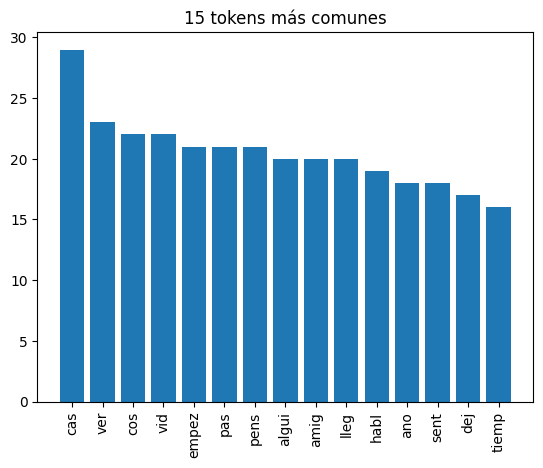

In [ ]:
# Obtener los 15 tokens normalizados más comunes
mas_comunes_norm = frecuencias_norm.most_common(15)

# Separar las palabras y sus valores para el gráfico
palabras_norm = [x[0] for x in mas_comunes_norm]
valores_norm = [x[1] for x in mas_comunes_norm]

# Crear y mostrar el gráfico de barras de los tokens normalizados más comunes
plt.figure()
plt.bar(palabras_norm, valores_norm)
plt.xticks(rotation=90)
plt.title("15 tokens más comunes")
plt.show()

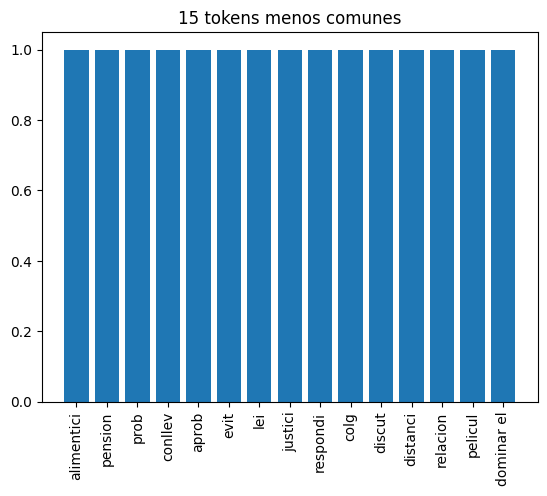

In [ ]:
# Obtener los 15 tokens normalizados menos comunes
menos_comunes_norm = list(reversed(frecuencias_norm.most_common()))[:15]

# Separar las palabras y sus valores para el gráfico
palabras_norm = [x[0] for x in menos_comunes_norm]
valores_norm = [x[1] for x in menos_comunes_norm]

# Crear y mostrar el gráfico de barras de los tokens normalizados menos comunes
plt.figure()
plt.bar(palabras_norm, valores_norm)
plt.xticks(rotation=90)
plt.title("15 tokens menos comunes")
plt.show()

In [ ]:
# Contar el número de tokens normalizados con una frecuencia de 1
tokens_raros_norm = sum(1 for token, freq in frecuencias_norm.items() if freq == 1)
print("Número de tokens raros (frecuencia = 1):", tokens_raros_norm)

Número de tokens raros (frecuencia = 1): 876


In [ ]:
# Crear bigramas a partir de los tokens normalizados
bigramas_norm = zip(tokens_norm, tokens_norm[1:])
# Calcular la frecuencia de cada bigrama normalizado
frecuencia_bigramas_norm = Counter(bigramas_norm)

# Obtener los 15 bigramas normalizados más comunes
top_15_bigramas_norm = frecuencia_bigramas_norm.most_common(15)

# Imprimir los 15 bigramas normalizados más comunes
print("Top 15 Bigramas:")
for bg, freq in top_15_bigramas_norm:
    print(bg, "->", freq)

Top 15 Bigramas:
('padr', 'madr') -> 3
('lleg', 'noch') -> 3
('dej', 'cas') -> 3
('karm', 'comentari') -> 3
('cas', 'unic') -> 2
('aprend', 'espanol') -> 2
('dorm', 'hor') -> 2
('suen', 'form') -> 2
('establec', 'rutin') -> 2
('amig', 'conoc') -> 2
('pas', 'ano') -> 2
('aparec', 'pregunt') -> 2
('punt', 'vist') -> 2
('famili', 'amig') -> 2
('inici', 'cos') -> 2


In [ ]:
# Crear trigramas a partir de los tokens normalizados
trigramas_norm = zip(tokens_norm, tokens_norm[1:], tokens_norm[2:])
# Calcular la frecuencia de cada trigrama normalizado
frecuencia_trigramas_norm = Counter(trigramas_norm)

# Obtener los 15 trigramas normalizados más comunes
top_15_trigramas_norm = frecuencia_trigramas_norm.most_common(15)

# Imprimir los 15 trigramas normalizados más comunes
print("Top 15 Trigramas:")
for tg, freq in top_15_trigramas_norm:
    print(tg, "->", freq)

Top 15 Trigramas:
('luz', 'titil', 'luz') -> 2
('padr', 'madr', 'herman') -> 2
('madr', 'herman', 'hij') -> 2
('karm', 'public', 'karm') -> 2
('public', 'karm', 'comentari') -> 2
('prueb', 'patern', 'obligatori') -> 2
('loc', 'pregunt', 'ubic') -> 1
('pregunt', 'ubic', 'numer') -> 1
('ubic', 'numer', 'telefon') -> 1
('numer', 'telefon', 'instagram') -> 1
('telefon', 'instagram', 'tiktok') -> 1
('instagram', 'tiktok', 'dni') -> 1
('tiktok', 'dni', 'razon') -> 1
('dni', 'razon', 'rar') -> 1
('razon', 'rar', 'estareis') -> 1


## Parte de inglés

In [ ]:
# Cargar el modelo de spaCy para inglés y configurar el stemmer
nlp = spacy.load("en_core_web_sm")
stemmer = SnowballStemmer("english")

In [ ]:
# Nombre del archivo de texto en inglés
nombre_archivo = "textosingles.txt"

# Leer el contenido y eliminar el divisor propuesto
with open(nombre_archivo, "r", encoding="utf-8") as f:
    texto = f.read()
    texto = texto.replace("===", "")

In [ ]:
# Procesar el texto con spaCy
doc = nlp(texto)

# Extraer tokens, excluyendo signos de puntuación y espacios
tokens = [
    token.text
    for token in doc
    if not token.is_punct and not token.is_space
]

In [ ]:
# Calcular y mostrar el número total de tokens
total_tokens = len(tokens)
print("Total de tokens:", total_tokens)

Total de tokens: 12712


In [ ]:
# Calcular y mostrar el número de tokens únicos (vocabulario)
tokens_unicos = len(set(tokens))
print("Número de tokens únicos:", tokens_unicos)

Número de tokens únicos: 2326


In [ ]:
# Calcular la frecuencia de cada token
frecuencias = Counter(tokens)

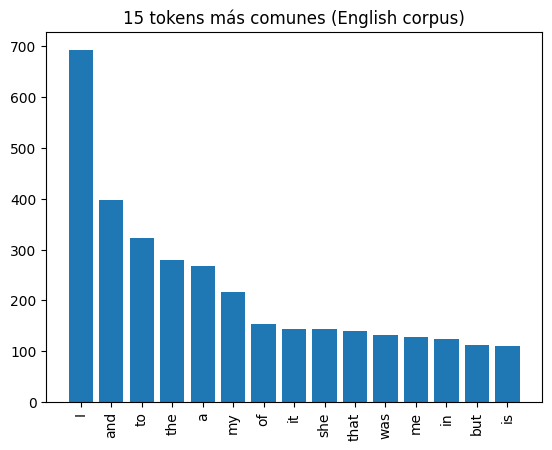

In [ ]:
# Obtener los 15 tokens más comunes
mas_comunes = frecuencias.most_common(15)

palabras = [x[0] for x in mas_comunes]
valores = [x[1] for x in mas_comunes]

# Crear gráfico de barras para los tokens más comunes
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens más comunes (English corpus)")
plt.show()

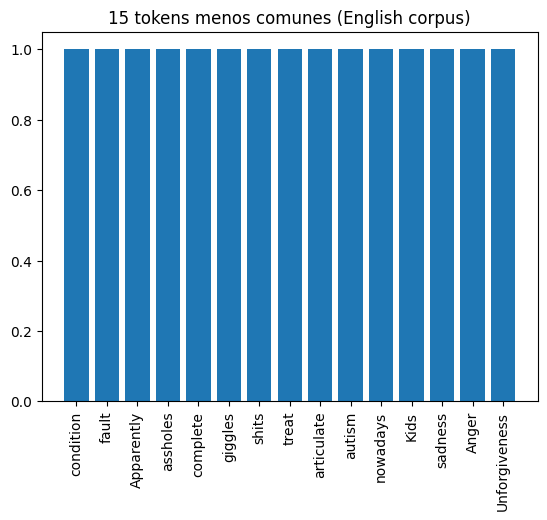

In [ ]:
# Obtener los 15 tokens menos comunes
menos_comunes = list(reversed(frecuencias.most_common()))[:15]

palabras = [x[0] for x in menos_comunes]
valores = [x[1] for x in menos_comunes]

# Crear gráfico de barras para los tokens menos comunes
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens menos comunes (English corpus)")
plt.show()

In [ ]:
# Generar bigramas a partir de los tokens
bigramas = list(ngrams(tokens, 2))

# Calcular frecuencia de bigramas
frecuencia_bigramas = Counter(bigramas)

# Obtener e imprimir los 10 bigramas más comunes
bigramas_comunes = frecuencia_bigramas.most_common(10)
print("10 bigramas más comunes:")
for bigrama, frecuencia in bigramas_comunes:
    print(bigrama, ":", frecuencia)

10 bigramas más comunes:
('I', '’m') : 56
('and', 'I') : 50
('I', 'was') : 48
('I', 'have') : 36
('I', 'do') : 36
('but', 'I') : 34
('I', "'m") : 29
('I', 'am') : 27
('in', 'the') : 24
('it', 'was') : 24


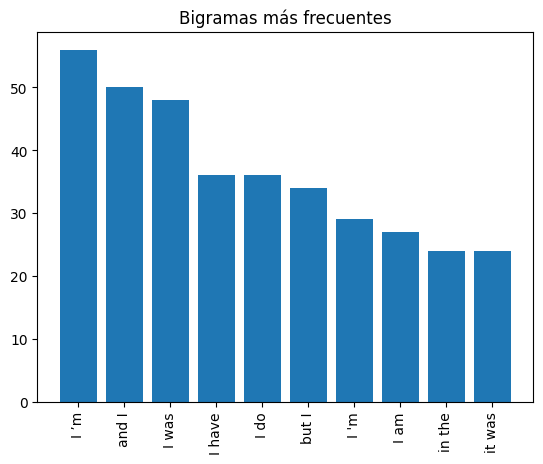

In [ ]:
# Preparar los datos de bigramas para la visualización
bigramas_texto = [" ".join(b) for b, f in bigramas_comunes]
frecuencias_bigramas = [f for b, f in bigramas_comunes]

# Crear y mostrar el gráfico de barras para los bigramas más frecuentes
plt.figure()
plt.bar(bigramas_texto, frecuencias_bigramas)
plt.xticks(rotation=90)
plt.title("Bigramas más frecuentes")
plt.show()

In [ ]:
# Generar trigramas a partir de los tokens
trigramas = list(ngrams(tokens, 3))

# Calcular la frecuencia de cada trigrama
frecuencia_trigramas = Counter(trigramas)

# Obtener los 10 trigramas más comunes
trigramas_comunes = frecuencia_trigramas.most_common(10)

# Imprimir los trigramas más comunes encontrados
print("10 trigramas más comunes:")
for trigrama, frecuencia in trigramas_comunes:
    print(trigrama, ":", frecuencia)

10 trigramas más comunes:
('I', 'do', "n't") : 13
('I', 'do', 'n’t') : 10
('I', 'want', 'to') : 10
('I', 'have', 'been') : 7
('I', 'feel', 'like') : 7
('I', '’m', 'not') : 6
('I', "'ve", 'been') : 6
('I', 'told', 'her') : 6
('that', 'I', '’m') : 5
('I', '’ve', 'been') : 5


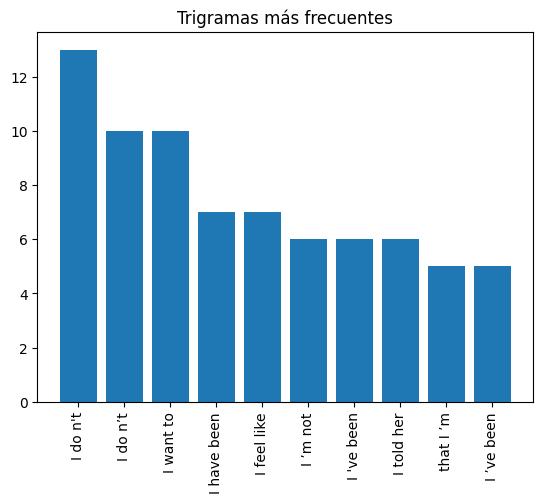

In [ ]:
# Preparar los datos de trigramas para la visualización
trigramas_texto = [" ".join(t) for t, f in trigramas_comunes]
frecuencias_trigramas = [f for t, f in trigramas_comunes]

# Crear y mostrar el gráfico de barras para los trigramas más frecuentes
plt.figure()
plt.bar(trigramas_texto, frecuencias_trigramas)
plt.xticks(rotation=90)
plt.title("Trigramas más frecuentes")
plt.show()

In [ ]:
# Convertir tokens a minúsculas para normalización
tokens_lower = [token.lower() for token in tokens]

In [ ]:
# Filtrar tokens que sean numéricos
tokens_sin_numeros = [
    token for token in tokens_lower
    if not token.isdigit()
]

In [ ]:
# Limpiar tokens eliminando caracteres que no sean letras
tokens_limpios = [
    re.sub(r'[^a-zA-Z]', '', token)
    for token in tokens_sin_numeros
]

# Eliminar strings vacíos resultantes de la limpieza
tokens_limpios = [t for t in tokens_limpios if t != ""]

In [ ]:
# Cargar lista de stop words y filtrar los tokens
stopwords = nlp.Defaults.stop_words

tokens_sin_stopwords = [
    token for token in tokens_limpios
    if token not in stopwords
]

In [ ]:
# Unir tokens para procesar y extraer lemas (formas base)
doc_normalizado = nlp(" ".join(tokens_sin_stopwords))

tokens_lematizados = [
    token.lemma_
    for token in doc_normalizado
]

In [ ]:
# Aplicar stemming a los tokens lematizados
tokens_stem = [
    stemmer.stem(token)
    for token in tokens_lematizados
]

In [ ]:
# Asignar los tokens procesados a la variable final de tokens normalizados
tokens_normalizados = tokens_stem

In [ ]:
# Calcular y mostrar el total de tokens tras el proceso de normalización
total_tokens_norm = len(tokens_normalizados)
print("Total de tokens después de normalización:", total_tokens_norm)

Total de tokens después de normalización: 4967


In [ ]:
# Calcular y mostrar la cantidad de tokens únicos (vocabulario) normalizados
tokens_unicos_norm = len(set(tokens_normalizados))
print("Tokens únicos después de normalización:", tokens_unicos_norm)

Tokens únicos después de normalización: 1389


In [ ]:
# Calcular la frecuencia de cada token normalizado
frecuencias_norm = Counter(tokens_normalizados)

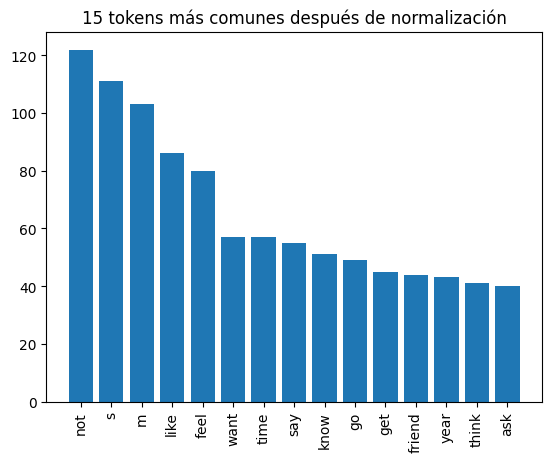

In [ ]:
# Obtener los 15 tokens normalizados más comunes
mas_comunes_norm = frecuencias_norm.most_common(15)

palabras = [x[0] for x in mas_comunes_norm]
valores = [x[1] for x in mas_comunes_norm]

# Crear gráfico de barras para los tokens más comunes tras la normalización
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens más comunes después de normalización")
plt.show()

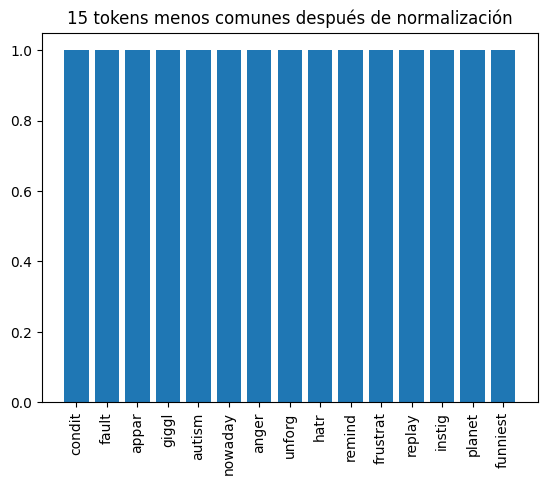

In [ ]:
# Obtener los 15 tokens normalizados menos comunes
menos_comunes_norm = list(reversed(frecuencias_norm.most_common()))[:15]

palabras = [x[0] for x in menos_comunes_norm]
valores = [x[1] for x in menos_comunes_norm]

# Crear gráfico de barras para los tokens menos comunes tras la normalización
plt.figure()
plt.bar(palabras, valores)
plt.xticks(rotation=90)
plt.title("15 tokens menos comunes después de normalización")
plt.show()